# Evaluating the Association Between Grade 8 ELA IAB Exposure and Summative Pass Rates
**Author:** Christopher DuPée  
**Date**: April 2026

## Question
In a prior analysis (see SHAP Feature Importance Report), feature importance modeling identified same-year assessments as strong predictors of ELA summative outcomes. However, many of these features were concurrent summative tests, limiting their usefulness as actionable predictors.

One formative assessment—the Grade 8 ELA Read Literary Texts (IAB)—also showed high feature importance, suggesting potential predictive value earlier in the academic year. Because feature importance reflects predictive contribution rather than causal or outcome-based effects, further evaluation is needed.

This analysis investigates whether exposure to this formative assessment is associated with differences in pass rates on the Grade 8 ELA Summative. To ensure alignment between intervention and outcome, the analysis is restricted to Grade 8 students.


## Method
We compare pass rates between exposed and unexposed groups using a Bayesian Beta–Binomial model ($Beta(2,2)$) to estimate uncertainty, alongside a two-proportion z-test as a frequentist comparison.


## Import

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import hypo_helper_ as h
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.proportion import confint_proportions_2indep

## Loading and Cleaning

In [2]:
path = 'data/portfolio_test_data.csv'

columns = ['StudentIdentifier', 'AssessmentName', 'ScaleScoreAchievementLevel']

df = h.load_data(path, columns)
df = h.pivot(df)

## Feature Cleanup

In [3]:
#df = h.singular_ela_column(df)

interest_columns = ['StudentIdentifier', 'Grade 8 ELA - Read Literary Texts (IAB)', 'ELA Summative Grade 8']
analysis_data = h.get_interest_column(df, interest_columns)

analysis_data = h.make_exposed(analysis_data, 'Grade 8 ELA - Read Literary Texts (IAB)')
analysis_data = h.get_pass_fail(analysis_data, 'ELA Summative Grade 8')

In [4]:
# Examine data to make sure it's what we need
analysis_data.head()

,StudentIdentifier,Grade 8 ELA - Read Literary Texts (IAB),ELA Summative Grade 8,exposed,pass
8,7f87556c7b6046ade3e9f2cbbb7d1213,NaN,1.0,False,False
9,4b73710870554f504e0708651e8290fb,NaN,2.0,False,False
10,291eb58bdf88f997f8a0d1b1d65fca15,NaN,3.0,False,True
11,44ad35bf0a78233329417a0027447fb3,NaN,2.0,False,False
12,ce894a0c981401600b42af4d7641f99f,NaN,2.0,False,False


## Filter Cohorts

In [5]:
A = analysis_data[analysis_data['exposed'] == True]
B = analysis_data[analysis_data['exposed'] == False]

## Summarize

In [6]:
k_A = A["pass"].sum()
n_A = len(A)

k_B = B["pass"].sum()
n_B = len(B)

## Posterior Sampling

In [7]:
samples = 10000

pA = np.random.beta(2 + k_A, 2 + n_A - k_A, samples)
pB = np.random.beta(2 + k_B, 2 + n_B - k_B, samples)

diff = pA - pB

## Frequentist Test

In [15]:
# successes (passes)
successes = np.array([k_A, k_B])

# total observations
nobs = np.array([n_A, n_B])

# two-sided test (you can also use 'larger')
stat, pval = proportions_ztest(successes, nobs, alternative='two-sided')


ci_low, ci_high = confint_proportions_2indep(
    k_A, n_A,
    k_B, n_B,
    method='wald'
)


## Results

In [16]:
print("P(A > B):", np.mean(diff > 0))
print("Mean diff:", np.mean(diff))
print("95% CI:", np.quantile(diff, [0.025, 0.975]))

print("Z-statistic:", stat)
print("p-value:", pval)
print("95% CI for difference in proportions:", (ci_low, ci_high))


P(A > B): 0.8959
Mean diff: 0.05407811043213342
95% CI: [-0.02917376  0.13646431]
Z-statistic: 1.256831631195565
p-value: 0.2088146095374359
95% CI for difference in proportions: (np.float64(-0.030229583195776885), np.float64(0.1371776293372416))


### Bayesian
$P(A > B) = 0.896$  
Mean diff ≈ +5.4%  
95% CI ≈ [-3%, +13.6%]  

### Frequentist
p ≈ 0.21 → not statistically significant  
CI ≈ [-3%, +13.7%] → also includes zero  


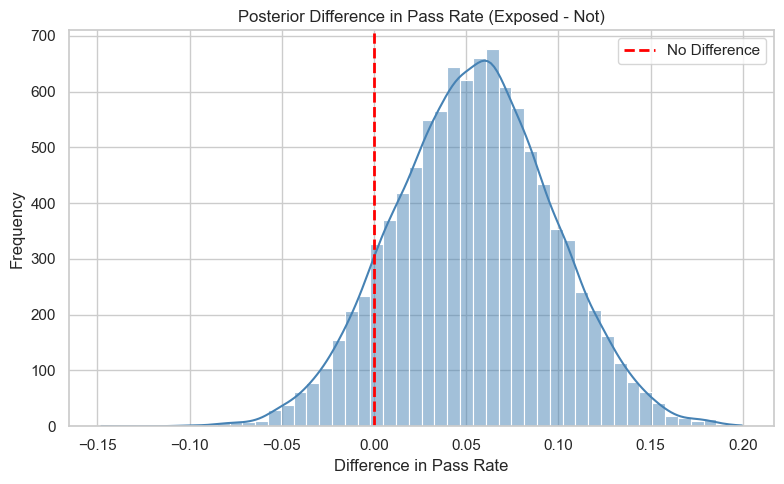

In [9]:
sns.set(style='whitegrid')

plt.figure(figsize = (8,5))

sns.histplot(diff, bins=50, kde = True, color = 'steelblue')

plt.axvline(0, color='red', linestyle = '--', linewidth = 2, label = 'No Difference')


plt.title("Posterior Difference in Pass Rate (Exposed - Not)")
plt.xlabel("Difference in Pass Rate")
plt.ylabel("Frequency")

plt.legend()
plt.tight_layout()
plt.show()

## Interpretation
The posterior probability that the exposed group has a higher pass rate is approximately 0.90, suggesting a likely positive association. The estimated effect size is about +5 percentage points, though the 95% credible interval ranges from approximately -3% to +14%, indicating substantial uncertainty.
The frequentist test similarly does not find statistically significant evidence of a difference $ (p\approx 0.21) $.  
Overall, the results suggest a potentially positive effect, but the evidence is not strong enough to support a definitive conclusion.  
## Limitations
Because exposure was not randomly assigned and cohorts vary across groups, this analysis reflects association rather than causation. Additionally, unobserved differences between classrooms or student populations may influence results. These are standard limitations in observational educational data.  
## Recommendations
The results suggest that the IAB may be a useful early indicator of summative performance, but further evaluation—ideally with more controlled comparisons or additional data—is recommended before making instructional or policy decisions based on this signal.